Fundamentals of Deep Learning Models

# Lab 07-1: YOLO for Object Detection
## Exercise: Implement YOLO-v1 loss function

This exercise implements the **YOLO-v1 loss function** (Section 7.5) that jointly optimizes bounding box localization, objectness confidence, and class prediction in a single unified objective. The total loss $L_{\text{total}} = L_{xy} + L_{wh} + L_{\text{obj}} + L_{\text{class}}$ is defined in Eq. (7.8), with individual components specified in Eqs. (7.9)–(7.13).

**Implementation note:** This implementation adopts several modifications from later YOLO variants for improved numerical stability: sigmoid activation for confidence scores, softmax for class probabilities, and log-space parameterization for bounding box height and width. These differ from the original YOLO-v1 which uses raw MSE on all outputs (Section 7.5).

### Prepare synthetic ground truth and predictions

Verifying a loss function for object detection requires carefully constructed ground-truth and prediction tensors with known bounding box locations, confidence scores, and class labels. The output tensor format follows the YOLO-v1 convention: each grid cell predicts $C_{\text{cell}} = 5B + N_{\text{class}} = 5 \times 2 + 20 = 30$ values (Eq. 7.7), organized as two sets of 5 bounding box parameters (confidence, $y$, $x$, $h$, $w$) followed by 20 class probabilities.

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
Matplotlib version: 3.10.0
Num GPUs Available:  0


In [ ]:
np.random.seed(6)

n_batch = 2

# Track object locations for visualization
o_locatn = np.zeros((n_batch,7,7))

# Ground truth tensor: (batch, S, S, 5B + N_class) = (2, 7, 7, 30)
y_tr = np.zeros(shape=(n_batch,7,7,30), dtype=float)
# Prediction tensor: same shape, with raw logits before activation
y_tm = np.zeros(shape=(n_batch,7,7,30), dtype=float)

for n in range(n_batch):

    # Generate random bounding box corners and slightly perturbed predictions
    obj_bbox = np.random.rand(8,4)
    prd_bbox = np.clip(obj_bbox + (np.random.rand(8,4) * 0.05), a_min=0.0, a_max=1.0-1e-8)
    n_object = np.random.randint(low=4, high=8)

    for i in range(n_object):
        # --- Ground truth ---
        tbox = np.zeros((4))
        tbox[0:2] = np.minimum(obj_bbox[i,0:2], obj_bbox[i,2:4])  # bottom-left (y,x)
        tbox[2:4] = np.maximum(obj_bbox[i,0:2], obj_bbox[i,2:4])  # top-right (y,x)
        c_y, c_x = (tbox[0:2] + tbox[2:4]) / 2   # center (y,x)
        c_h, c_w = tbox[2:4] - tbox[0:2]          # height, width
        i_y, i_x = int(c_y*7), int(c_x*7)         # grid cell indices
        c_y, c_x = c_y*7 - i_y, c_x*7 - i_x      # offset within cell (Eq. 7.5)

        # Box 1: responsible predictor (confidence=1), Box 2: null (confidence=0)
        tbx1 = np.array([1.0, c_y, c_x, c_h, c_w])
        tbx2 = np.array([0.0, c_y, c_x, c_h, c_w])
        # One-hot class label
        tcls = np.zeros((20))
        class_num = np.random.randint(20)
        tcls[class_num] = 1.0
        y_tr[n, i_y, i_x] = np.concatenate((tbx1, tbx2, tcls), axis=0)

        o_locatn[n, i_y, i_x] = class_num  # for display purpose only

        # --- Predictions (raw logits) ---
        pbox = np.zeros((4))
        pbox[0:2] = np.minimum(prd_bbox[i,0:2], prd_bbox[i,2:4])
        pbox[2:4] = np.maximum(prd_bbox[i,0:2], prd_bbox[i,2:4])
        c_y, c_x = (pbox[0:2] + pbox[2:4]) / 2
        c_h, c_w = pbox[2:4] - pbox[0:2]
        c_h = np.log(c_h); c_w = np.log(c_w)      # log-space for h,w (exp applied later)
        i_y, i_x = int(c_y*7), int(c_x*7)
        c_y, c_x = c_y*7 - i_y, c_x*7 - i_x
        # Confidence logits (sigmoid applied later)
        if np.random.uniform()>0.5:
            cnf1 = np.random.uniform(0.9,3)
            cnf2 = np.random.uniform(-3,-0.9)
        else:
            cnf2 = np.random.uniform(0.9,3)
            cnf1 = np.random.uniform(-3,-0.9)
        pbx1 = np.array([cnf1, c_y, c_x, c_h, c_w])
        pbx2 = np.array([cnf2, c_y, c_x, c_h, c_w])
        # Class logits (softmax applied later)
        pcls = np.random.uniform(-3,-0.9,size=(20))
        pcls[class_num] = np.random.uniform(0.9,3)
        y_tm[n, i_y, i_x] = np.concatenate((pbx1, pbx2, pcls), axis=0)

y_true = tf.cast(y_tr, dtype=tf.float32)
y_pred = tf.cast(y_tm, dtype=tf.float32)

In [ ]:
def sigmoid(x):
    """Numerically stable sigmoid for visualization (not used in loss computation)."""
    x = np.where(x < 0, np.exp(x)/(1 + np.exp(x)), 1/(1 + np.exp(-x)))
    return x

[[ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 14.  0.  6.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  9.  0.]
 [ 0.  6.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]]


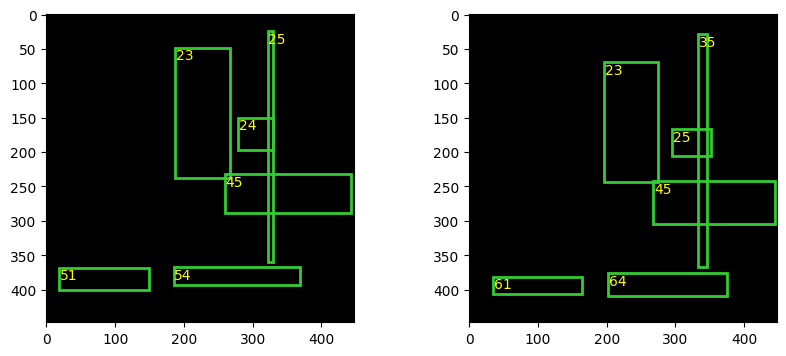

In [ ]:
# Display ground-truth (left) and predicted (right) bounding boxes
print(o_locatn[0])

sample = np.zeros((448,448,3))
img_h, img_w, _ = sample.shape

plt.figure(figsize=(10,4))

# Left: ground-truth boxes (from true tensor, confidence == 1)
plt.subplot(1, 2, 1)
plt.imshow(sample)
axs = plt.gca()
for j in range(7):
    for i in range(7):
        if y_true[0,j,i,0]==1:
            c_y, c_x, c_h, c_w = y_true[0,j,i,1:5]
            c_y, c_x = (c_y + j)/7, (c_x + i)/7
            obj_y, obj_x, obj_h, obj_w = (c_y-c_h/2)*img_h, (c_x-c_w/2)*img_w, c_h*img_h, c_w*img_w
            bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h, linewidth=2, edgecolor='limegreen', fill = False)
            axs.add_patch(bbox)
            plt.text(obj_x+1, obj_y+17, str(j)+str(i), color='yellow')

# Right: predicted boxes (from pred tensor, sigmoid(confidence) > 0.5)
plt.subplot(1, 2, 2)
plt.imshow(sample)
axs = plt.gca()
for j in range(7):
    for i in range(7):
        if (sigmoid(y_pred[0,j,i,0])>0.5) or (sigmoid(y_pred[0,j,i,5])>0.5):
            c_y, c_x, c_h, c_w = y_pred[0,j,i,1:5]
            c_y, c_x = (c_y + j)/7, (c_x + i)/7
            c_h, c_w = np.exp(c_h), np.exp(c_w)
            obj_y, obj_x, obj_h, obj_w = (c_y-c_h/2)*img_h, (c_x-c_w/2)*img_w, c_h*img_h, c_w*img_w
            bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h, linewidth=2, edgecolor='limegreen', fill = False)
            axs.add_patch(bbox)
            plt.text(obj_x+1, obj_y+17, str(j)+str(i), color='yellow')

plt.show()

### Loss function for YOLO-v1

The YOLO-v1 total loss (Eq. 7.8) consists of four components:

**Location loss** $L_{xy}$ — MSE on center coordinates (Eq. 7.9):
$$ L_{xy} = \lambda_{\text{coord}} \sum_{i=1}^{S^2} \sum_{j=1}^{B} \mathbb{1}_{ij}^{\text{obj}} \left[ (\hat{x}_{ij} - x_i)^2 + (\hat{y}_{ij} - y_i)^2 \right] $$

**Size loss** $L_{wh}$ — MSE on square-rooted width and height (Eq. 7.10):
$$ L_{wh} = \lambda_{\text{coord}} \sum_{i=1}^{S^2} \sum_{j=1}^{B} \mathbb{1}_{ij}^{\text{obj}} \left[ (\sqrt{\hat{w}_{ij}} - \sqrt{w_i})^2 + (\sqrt{\hat{h}_{ij}} - \sqrt{h_i})^2 \right] $$

**Confidence loss** $L_{\text{obj}}$ — MSE on objectness score (Eq. 7.12):
$$ L_{\text{obj}} = \sum_{i=1}^{S^2} \sum_{j=1}^{B} \mathbb{1}_{ij}^{\text{obj}} (\hat{C}_{ij} - C_{ij})^2 + \lambda_{\text{noobj}} \sum_{i=1}^{S^2} \sum_{j=1}^{B} \mathbb{1}_{ij}^{\text{noobj}} (\hat{C}_{ij} - C_{ij})^2 $$

**Class probability loss** $L_{\text{class}}$ — MSE on class probabilities (Eq. 7.13):
$$ L_{\text{class}} = \sum_{i=1}^{S^2} \mathbb{1}_{i}^{\text{obj}} \sum_{k \in \mathcal{C}} (\hat{P}_i(k) - P_i(k))^2 $$

**Implementation notes:**
- The original YOLO-v1 evaluates confidence and class probabilities with MSE on raw values. This implementation uses **sigmoid** for confidence and **softmax** for class probabilities for improved numerical stability.
- Bounding box height and width are parameterized in **log-space** (as in YOLOv2/v3), so `exp()` is applied before the square-root operation in $L_{wh}$.
- The confidence target for the responsible predictor is simplified to $C_{ij} = 1$ rather than $\text{IoU}(B_T, B_P)$ as defined in Eq. (7.11).

In [ ]:
def yolo_loss_fn(y_true, y_pred):

    l_coord = 5.0  # lambda_coord (Section 7.5: lambda_coord = 5)
    l_noobj = 0.5  # lambda_noobj (Section 7.5: lambda_noobj = 0.5)
    n_grid = 7     # S = 7 grid resolution
    n_batch = tf.shape(y_true)[0]

    # Build grid index arrays for converting cell offsets to absolute coordinates (Eq. 7.5)
    i,j = tf.meshgrid(tf.range(0, n_grid, dtype=tf.float32),
                      tf.range(0, n_grid, dtype=tf.float32), indexing='ij')
    idx_tmp = tf.stack([i,j], axis=-1)                   # (S, S, 2)
    idx_ar0 = tf.reshape(idx_tmp, [1,n_grid,n_grid,1,2]) # (1,S,S,1,2)
    idx_arr = tf.repeat(idx_ar0, repeats=2, axis=-2)     # (1,S,S,2,2) for B=2 boxes

    # ---- (1) Parse ground truth tensor ----
    # Duplicate ground truth for B=2 box proposals for easy comparison
    y_true_1c = tf.expand_dims(y_true, axis=-2)          # (b,S,S,1,30)
    y_true_2c = tf.repeat(y_true_1c, repeats=2, axis=-2) # (b,S,S,2,30)

    ### START CODE HERE ###

    # Extract true center (y,x) offsets and convert to absolute coords (Eq. 7.5)
    true_o_yx = None                                     # (b,S,S,2,2) offset (y,x)
    true_c_yx = None                                     # (b,S,S,2,2) absolute (y,x)
    # Extract true box height and width
    true_c_hw = None                                     # (b,S,S,2,2) = (h,w)

    # Extract true one-hot class probabilities (last 20 values per cell)
    true_clss = None                                     # (b,S,S,20)

    ### END CODE HERE ###

    print('(1)', true_c_yx[0,2,3,0].numpy(), true_c_hw[0,2,3,0].numpy())

    # ---- (2) Parse prediction tensor ----
    # Reshape first 10 values into B=2 boxes of 5 params each
    y_pred_rs = tf.reshape(y_pred[..., :10], [n_batch,n_grid,n_grid,2,5]) # (b,S,S,2,5)

    ### START CODE HERE ###

    # Apply sigmoid to confidence logits → probability in [0,1]
    pred_conf = None                                      # (b,S,S,2)

    # Extract predicted center (y,x) offsets and convert to absolute coords (Eq. 7.5)
    pred_o_yx = None                                      # (b,S,S,2,2) offset (y,x)
    pred_c_yx = None                                      # (b,S,S,2,2) absolute (y,x)

    # Apply exp() to h,w logits (log-space parameterization)
    pred_c_hw = None                                      # (b,S,S,2,2) = (h,w)

    # Apply softmax to class logits → class probabilities
    pred_clss = None                                      # (b,S,S,20)

    ### END CODE HERE ###

    print('(2)', pred_c_yx[0,2,3,0].numpy(), pred_c_hw[0,2,3,0].numpy())

    # ---- (3) Compute IoU to determine responsible predictor (Eq. 7.1, 7.2) ----

    ### START CODE HERE ###

    # Convert center+size to corner coordinates for IoU computation
    true_b_yx = None                                     # (b,S,S,2,2) bottom-left
    true_t_yx = None                                     # (b,S,S,2,2) top-right
    pred_b_yx = None                                     # (b,S,S,2,2) bottom-left
    pred_t_yx = None                                     # (b,S,S,2,2) top-right

    # Compute intersection area
    ovrl_b_yx = None                                     # (b,S,S,2,2) intersection corner
    ovrl_t_yx = None                                     # (b,S,S,2,2) intersection corner
    ovrl_bxhw = None                                     # (b,S,S,2,2) clamp negative

    # Compute areas for IoU = intersection / union (Eq. 7.2)
    true_area = None                                     # (b,S,S,2)
    pred_area = None                                     # (b,S,S,2)
    ovrl_area = None                                     # (b,S,S,2)

    # IoU (Eq. 7.2)
    iou_value = None                                     # (b,S,S,2)

    ### END CODE HERE ###

    print('(3)', iou_value[0,2,3].numpy())

    # ---- (4) Generate indicator masks: 1^obj_ij and 1^noobj_ij ----

    ### START CODE HERE ###

    # Responsible predictor = the one with higher IoU (Section 7.5)
    iou_biggr = None                                     # (b,S,S,1) 1 if box 1 has higher IoU, else 0
    iou_smalr = None                                     # (b,S,S,1) 1 if box 2 has higher IoU, else 0
    iou_bmssk = None                                     # (b,S,S,2) higher-IoU mask

    # 1^obj_ij: 1 if object in cell i AND box j is responsible (Eq. 7.9)
    true_objt = None                                     # (b,S,S,1) object presence
    true_objc = None                                     # (b,S,S,2) = 1^obj_ij
    # 1^noobj_ij: complement (Eq. 7.12)
    true_nbjc = None                                     # (b,S,S,2) = 1^noobj_ij

    true_conf = None                                     # (b,S,S,2) = confidence of responsible box

    ### END CODE HERE ###

    print('(4)', true_objc[0,2,3].numpy(), true_nbjc[0,2,3].numpy())

    # ---- (5) Compute individual loss components ----

    ### START CODE HERE ###

    # Location loss L_xy (Eq. 7.9): MSE on center coordinates
    loss_cyx0 = None                                     # (b,S,S,2,2)
    loss_c_yx = None                                     # (b,S,S,2)

    # Size loss L_wh (Eq. 7.10): MSE on sqrt of width and height
    loss_chw0 = None                                     # (b,S,S,2,2)
    loss_c_hw = None                                     # (b,S,S,2)

    # Coordinate loss = lambda_coord * sum(L_xy + L_wh)
    loss_coordinate = None                               # (b,)

    # Confidence loss L_obj (Eq. 7.12): target=IoU for responsible box, 0 otherwise
    loss_ob_c = None                                     # (b,S,S,2) object term
    loss_nb_c = None                                     # (b,S,S,2) no-obj: true_conf=0

    loss_confidence = None                               # (b,)

    # Class probability loss L_class (Eq. 7.13): MSE on class probs, only for obj cells
    loss_clss = None                                     # (b,S,S,20)
    loss_classification = None                           # (b,)

    ### END CODE HERE ###

    loss = tf.reduce_mean(loss_coordinate + loss_confidence + loss_classification)

    return loss, loss_coordinate, loss_confidence, loss_classification

In [ ]:
# Compute loss and verify against expected output
loss, loss_yxhw, loss_conf, loss_clss = yolo_loss_fn(y_true, y_pred)

print(loss.numpy())
print(loss_yxhw[0].numpy(), loss_conf[0].numpy(), loss_clss[0].numpy())

(1) [0.31873703 0.50692976] [0.42216069 0.17624463]
(2) [0.34851164 0.5257868 ] [0.38797492 0.1737115 ]
(3) [0.70415175 0.70415175]
(4) [1. 0.] [0. 1.]
22.133316
14.028306 13.940895 4.396268


**Expected Output:**
```
(1) [0.31873703 0.50692976] [0.42216069 0.17624463]
(2) [0.34851164 0.5257868 ] [0.38797492 0.1737115 ]
(3) [0.70415175 0.70415175]
(4) [1. 0.] [0. 1.]
22.133316
14.028306 13.940895 4.396268
```

(c) 2026 S. W. Lee